In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
data = pd.read_csv("../Dataset.csv")

In [6]:
df = pd.read_csv("../Dataset.csv")
df.head()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [8]:
df = df.drop(columns=['Company', 'Date Joined'], errors='ignore')

def convert_money(x):
    try:
        if pd.isna(x):
            return 0
        x = str(x).replace(',', '').strip()
        if x == '' or x.lower() == 'unknown':
            return 0
        if 'B' in x:
            return float(x.replace('B', '')) * 1e9
        elif 'M' in x:
            return float(x.replace('M', '')) * 1e6
        else:
            return float(x)
    except:
        return 0

for col in ['Valuation', 'Funding']:
    if col in df.columns:
        df[col] = df[col].apply(convert_money)


df = df.fillna(0)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

df.head()

,Valuation,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,0.0,1,15,9,1,2012,0.0,805
1,0.0,13,98,44,3,2002,0.0,335
2,0.0,6,217,9,1,2008,0.0,962
3,0.0,8,201,44,3,2010,0.0,551
4,0.0,8,223,38,2,2005,0.0,505


In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_data[:5]

array([[ 0.        , -1.94817237, -1.61504761, -1.48904082, -1.36469391,
        -0.15725589,  0.        ,  0.89402986],
       [ 0.        ,  1.30669482, -0.51510205,  0.80371486,  0.69096003,
        -1.91289862,  0.        , -0.64432394],
       [ 0.        , -0.59197771,  1.06192832, -1.48904082, -1.36469391,
        -0.85951299,  0.        ,  1.40790549],
       [ 0.        , -0.04949984,  0.84989063,  0.80371486,  0.69096003,
        -0.50838444,  0.        ,  0.06266419],
       [ 0.        , -0.04949984,  1.14144246,  0.41067103, -0.33686694,
        -1.3862058 ,  0.        , -0.08789809]])

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


K=2, Labels: [0 1 0 ... 0 1 1]
K=3, Labels: [0 1 0 ... 0 1 2]
K=4, Labels: [0 1 0 ... 0 1 3]


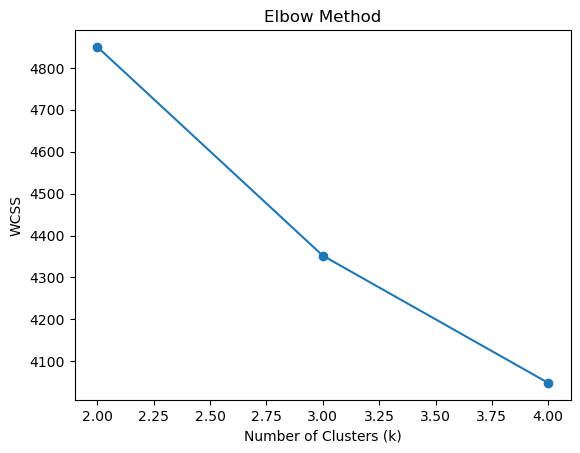

In [10]:
wcss = []
K = [2, 3, 4]

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    print(f"K={k}, Labels:", kmeans.labels_)

# Elbow curve
plt.plot(K, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [11]:
for eps in [0.5, 1.0]:
    db = DBSCAN(eps=eps, min_samples=2)
    labels = db.fit_predict(scaled_data)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print(f"\neps={eps}")
    print("Clusters:", clusters)
    print("Noise points:", noise)


eps=0.5
Clusters: 101
Noise points: 468

eps=1.0
Clusters: 34
Noise points: 134


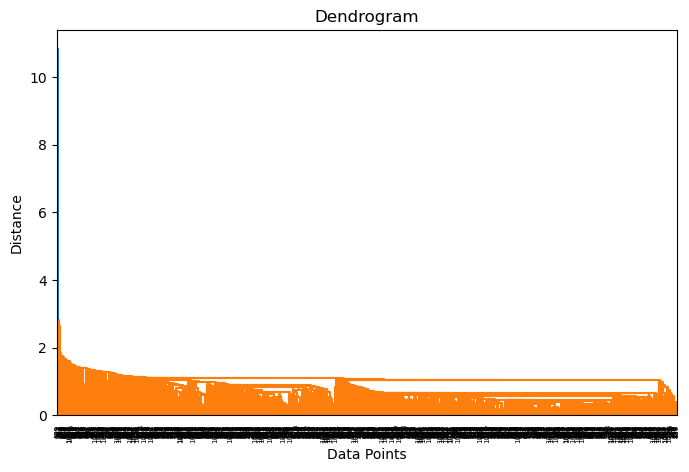

In [12]:
linked = linkage(scaled_data, method='single')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()